# 2장 4강: 이벤트 로그 기반 AARRR 퍼널 집계 및 시각화 — 실습문제

## 실습 목표

- 계정·구독·기능 사용 데이터를 연결하여 퍼널 단계 도달 기록을 만들 수 있다.
- `groupby()`와 `nunique()`로 단계별 고유 계정 수를 집계할 수 있다.
- 전 단계 대비 전환율과 최초 단계 대비 전체 전환율을 계산할 수 있다.
- 퍼널을 가로 막대그래프로 시각화하고 이탈 집중 구간을 찾을 수 있다.
- 수치에서 확인한 이탈 구간을 바탕으로 개선 가설과 검증 방법을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습에서는 다음 네 단계를 누적 퍼널로 정의합니다.

| 단계 | 도달 조건 |
|---|---|
| Acquisition | 관찰 종료일보다 30일 이상 앞서 가입한 계정 |
| Activation | 가입 후 30일 이내 첫 구독을 시작한 계정 |
| Retention | Activation 계정 중 첫 구독 시작 30일 후에도 유효한 기능 사용 기록이 있는 계정 |
| Revenue | Retention 계정 중 첫 구독이 체험판이 아니고 `mrr_amount > 0`인 계정 |

> Ravenstack 데이터에는 다른 사용자를 추천한 행동을 뜻하는 Referral 이벤트가 없습니다. `referral_source`는 **현재 계정이 유입된 경로**이므로 Referral 행동으로 잘못 사용하지 않고, 이번 실습에서는 측정 가능한 Acquisition~Revenue 4단계만 분석합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치를 확인하세요.
5. 날짜 컬럼을 날짜형으로 변환하세요.
6. 계정별 가장 이른 구독을 `first_subscription`으로 만드세요.
7. 기능 사용 기록에 첫 구독 정보를 결합하고, 구독 시작 전 또는 종료 후 기록을 제외한 `valid_usage`를 만드세요.
8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 날짜를 `observation_cutoff`으로 정하세요.

> 가입 직후 30일이 지나지 않은 계정은 Retention 도달 기회가 부족하므로 분석 대상에서 제외합니다.

In [1]:
# 실습 준비 코드를 작성하세요.
# ----------------------------------------------------
# 1. 필요한 라이브러리 불러오기
# ----------------------------------------------------
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 2. 세 CSV 파일 불러오기
# ----------------------------------------------------
# 실행 환경 경로에 맞게 파일명을 지정하세요.
accounts = pd.read_csv("ravenstack_accounts.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

# ----------------------------------------------------
# 3. 각 데이터의 행과 열 개수, 상위 5개 행 확인
# ----------------------------------------------------
print(f"accounts shape: {accounts.shape}")
display(accounts.head())

print(f"subscriptions shape: {subscriptions.shape}")
display(subscriptions.head())

print(f"feature_usage shape: {feature_usage.shape}")
display(feature_usage.head())

# ----------------------------------------------------
# 4. 분석 대상 컬럼의 자료형과 결측치 확인
# ----------------------------------------------------
print("\n=== accounts 결측치 및 정보 ===")
print(
    accounts[
        ["account_id", "signup_date", "plan_tier", "is_trial", "churn_flag"]
    ].info()
)
print(
    accounts[
        ["account_id", "signup_date", "plan_tier", "is_trial", "churn_flag"]
    ]
    .isnull()
    .sum()
)

print("\n=== subscriptions 결측치 및 정보 ===")
print(
    subscriptions[
        [
            "subscription_id",
            "account_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount",
        ]
    ].info()
)
print(
    subscriptions[
        [
            "subscription_id",
            "account_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount",
        ]
    ]
    .isnull()
    .sum()
)

print("\n=== feature_usage 결측치 및 정보 ===")
print(
    feature_usage[
        ["usage_id", "subscription_id", "usage_date", "usage_count"]
    ].info()
)
print(
    feature_usage[
        ["usage_id", "subscription_id", "usage_date", "usage_count"]
    ]
    .isnull()
    .sum()
)

# ----------------------------------------------------
# 5. 날짜 컬럼을 날짜형(datetime)으로 변환
# ----------------------------------------------------
accounts["signup_date"] = pd.to_datetime(accounts["signup_date"])
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

print("\n날짜 변환 완료:")
print(f"- accounts['signup_date']: {accounts['signup_date'].dtype}")
print(f"- subscriptions['start_date']: {subscriptions['start_date'].dtype}")
print(f"- subscriptions['end_date']: {subscriptions['end_date'].dtype}")
print(f"- feature_usage['usage_date']: {feature_usage['usage_date'].dtype}")

# ----------------------------------------------------
# 6. 계정별 가장 이른 구독을 first_subscription으로 만들기
# ----------------------------------------------------
# 각 account_id별로 start_date가 가장 빠른 행 1건 추출
first_subscription = (
    subscriptions.sort_values(by=["account_id", "start_date"])
    .groupby("account_id")
    .first()
    .reset_index()
)

print(
    f"\n계정별 첫 구독 데이터(first_subscription) 생성 완료: {len(first_subscription):,}개 계정"
)
display(first_subscription.head())

# ----------------------------------------------------
# 7. 기능 사용 기록에 첫 구독 정보 결합 및 유효 사용(valid_usage) 생성
# ----------------------------------------------------
# 첫 구독의 subscription_id와 feature_usage를 결합
usage_with_first_sub = feature_usage.merge(
    first_subscription[
        [
            "subscription_id",
            "account_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount",
        ]
    ],
    on="subscription_id",
    how="inner",
)

# 구독 시작 전 또는 종료 후 기록 제외
valid_condition = (
    usage_with_first_sub["usage_date"] >= usage_with_first_sub["start_date"]
) & (
    usage_with_first_sub["end_date"].isna()
    | (usage_with_first_sub["usage_date"] <= usage_with_first_sub["end_date"])
)

valid_usage = usage_with_first_sub[valid_condition].copy()

print(f"\n첫 구독 연결 사용 행 수: {len(usage_with_first_sub):,}건")
print(f"유효 기능 사용(valid_usage) 행 수: {len(valid_usage):,}건")

# ----------------------------------------------------
# 8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 observation_cutoff 설정
# ----------------------------------------------------
max_usage_date = feature_usage["usage_date"].max()
observation_cutoff = max_usage_date - pd.Timedelta(days=30)

print(f"\n기능 사용 전체 최대 날짜 (max_usage_date): {max_usage_date.date()}")
print(f"관찰 기준일 (observation_cutoff, max - 30일): {observation_cutoff.date()}")

accounts shape: (500, 10)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


subscriptions shape: (5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


feature_usage shape: (25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



=== accounts 결측치 및 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   account_id   500 non-null    str  
 1   signup_date  500 non-null    str  
 2   plan_tier    500 non-null    str  
 3   is_trial     500 non-null    bool 
 4   churn_flag   500 non-null    bool 
dtypes: bool(2), str(3)
memory usage: 12.8 KB
None
account_id     0
signup_date    0
plan_tier      0
is_trial       0
churn_flag     0
dtype: int64

=== subscriptions 결측치 및 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   subscription_id  5000 non-null   str  
 1   account_id       5000 non-null   str  
 2   start_date       5000 non-null   str  
 3   end_date         486 non-null    str  
 4   is_trial         5000 non-null   bool 
 5   mrr_amount 

,account_id,subscription_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,A-00bed1,S-a7360b,2023-11-16,NaT,Basic,61,1159,13908,False,True,False,False,annual,True
1,A-00cac8,S-2e965d,2023-09-16,NaT,Pro,8,392,4704,False,False,False,False,monthly,True
2,A-0158bb,S-ba69a4,2024-05-30,NaT,Basic,25,0,0,True,False,False,False,monthly,True
3,A-016043,S-0e1d53,2024-08-02,2024-12-21,Basic,6,114,1368,False,False,False,False,annual,False
4,A-019782,S-b37d03,2023-06-08,2023-11-27,Pro,17,833,9996,False,True,False,False,annual,True



첫 구독 연결 사용 행 수: 2,488건
유효 기능 사용(valid_usage) 행 수: 786건

기능 사용 전체 최대 날짜 (max_usage_date): 2024-12-31
관찰 기준일 (observation_cutoff, max - 30일): 2024-12-01


---

## 필수 1. AARR 단계별 고유 계정 수와 전환율 계산하기

### 문제 1-1. 가입한 계정은 활성화·유지·유료 단계까지 얼마나 도달하는가?

#### 문제 해결 방향

각 단계의 조건을 만족하는 계정 ID를 만들고, 앞 단계에 도달한 계정만 다음 단계에 포함되도록 누적 조건을 적용하세요. 그다음 긴 형태의 `funnel_log`를 만들어 강의에서 배운 `groupby()`와 `nunique()`로 집계합니다.

#### 요구사항

1. `signup_date <= observation_cutoff`인 계정을 `funnel_base`로 만드세요.
2. Acquisition, Activation, Retention, Revenue 도달 여부를 불리언 컬럼으로 만드세요.
3. 단계별 도달 계정만 모아 `account_id`, `stage`로 구성된 `funnel_log`를 만드세요.
4. `groupby("stage")["account_id"].nunique()`로 고유 계정 수를 집계하세요.
5. `reindex()`를 사용해 `Acquisition → Activation → Retention → Revenue` 순서로 정렬하세요.
6. `calc_conversion_rates()` 함수를 작성하여 전 단계 대비 전환율과 전체 대비 전환율을 계산하세요.
7. 단계별 고유 계정 수와 두 전환율을 하나의 `funnel_summary`로 출력하세요.

#### 해석 질문

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?

#### 제출 결과

- `funnel_base`와 `funnel_log`
- `calc_conversion_rates()` 함수
- `funnel_summary`
- Q1~Q4 답변

In [2]:
# 필수 1 코드를 작성하세요.
import numpy as np
import pandas as pd

# ----------------------------------------------------
# 0. 실습 준비 단계 정렬 & valid_usage 확인
# ----------------------------------------------------
# observation_cutoff 설정 (마지막 사용일 - 30일)
observation_cutoff = feature_usage["usage_date"].max() - pd.Timedelta(days=30)

# 계정별 가장 이른 첫 구독
first_subscription = (
    subscriptions.sort_values(by=["account_id", "start_date"])
    .groupby("account_id")
    .first()
    .reset_index()
)

# [실습 준비 7번] 첫 구독과 feature_usage 결합 후 유효 사용 필터링
usage_with_first = feature_usage.merge(
    first_subscription[
        [
            "subscription_id",
            "account_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount",
        ]
    ],
    on="subscription_id",
    how="inner",
)

valid_condition = (
    usage_with_first["usage_date"] >= usage_with_first["start_date"]
) & (
    usage_with_first["end_date"].isna()
    | (usage_with_first["usage_date"] <= usage_with_first["end_date"])
)
valid_usage = usage_with_first[valid_condition].copy()

# ----------------------------------------------------
# 1. funnel_base 생성 (signup_date <= observation_cutoff)
# ----------------------------------------------------
funnel_base = accounts[accounts["signup_date"] <= observation_cutoff].copy()

# 첫 구독 정보 병합 (is_trial 중복 방지)
first_sub_renamed = first_subscription[
    ["account_id", "subscription_id", "start_date", "is_trial", "mrr_amount"]
].rename(
    columns={
        "start_date": "first_sub_date",
        "is_trial": "sub_is_trial",
        "mrr_amount": "sub_mrr",
    }
)
funnel_base = funnel_base.merge(first_sub_renamed, on="account_id", how="left")

# ----------------------------------------------------
# 2. 누적 퍼널 단계별 도달 조건
# ----------------------------------------------------
# [Acquisition]
funnel_base["is_acquisition"] = True

# [Activation] 가입 후 30일 이내 첫 구독 시작
days_to_sub = (
    funnel_base["first_sub_date"] - funnel_base["signup_date"]
).dt.days
funnel_base["is_activation"] = (
    funnel_base["is_acquisition"]
    & funnel_base["first_sub_date"].notna()
    & (days_to_sub >= 0)
    & (days_to_sub <= 30)
)

# [Retention] Activation 만족 & valid_usage에서 첫 구독 시작 30일 후 사용 기록 존재
# (valid_usage에는 이미 first_sub의 start_date가 포함되어 있음)
usage_after_30d = valid_usage[
    valid_usage["usage_date"]
    >= valid_usage["start_date"] + pd.Timedelta(days=30)
]
retained_account_ids = set(usage_after_30d["account_id"])

funnel_base["is_retention"] = funnel_base["is_activation"] & funnel_base[
    "account_id"
].isin(retained_account_ids)

# [Revenue] Retention 만족 & 첫 구독이 유료(체험X)이고 mrr > 0
funnel_base["is_revenue"] = (
    funnel_base["is_retention"]
    & (funnel_base["sub_is_trial"] == False)
    & (funnel_base["sub_mrr"] > 0)
)

# ----------------------------------------------------
# 3. 긴 형태의 funnel_log 생성
# ----------------------------------------------------
log_records = []
stage_mapping = [
    ("Acquisition", "is_acquisition"),
    ("Activation", "is_activation"),
    ("Retention", "is_retention"),
    ("Revenue", "is_revenue"),
]

for stage_name, bool_col in stage_mapping:
    reached = funnel_base[funnel_base[bool_col] == True]["account_id"]
    for acc_id in reached:
        log_records.append({"account_id": acc_id, "stage": stage_name})

funnel_log = pd.DataFrame(log_records)

# ----------------------------------------------------
# 4~5. groupby()와 nunique()로 집계
# ----------------------------------------------------
stage_order = ["Acquisition", "Activation", "Retention", "Revenue"]
stage_counts = (
    funnel_log.groupby("stage")["account_id"].nunique().reindex(stage_order)
)


# ----------------------------------------------------
# 6. calc_conversion_rates() 함수 정의
# ----------------------------------------------------
def calc_conversion_rates(counts_series: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({"accounts": counts_series})
    df["step_conv"] = (df["accounts"] / df["accounts"].shift(1)).fillna(1.0)
    df["overall_conv"] = df["accounts"] / df["accounts"].iloc[0]
    return df


# ----------------------------------------------------
# 7. funnel_summary 출력
# ----------------------------------------------------
funnel_summary = calc_conversion_rates(stage_counts)

print("=== 최종 퍼널 요약 (funnel_summary) ===")
display_summary = funnel_summary.copy()
display_summary["accounts"] = display_summary["accounts"].map(
    lambda x: f"{x:,}개"
)
display_summary["step_conv"] = display_summary["step_conv"].map(
    lambda x: f"{x:.1%}"
)
display_summary["overall_conv"] = display_summary["overall_conv"].map(
    lambda x: f"{x:.1%}"
)

display(display_summary)


=== 최종 퍼널 요약 (funnel_summary) ===


,accounts,step_conv,overall_conv
stage,,,
Acquisition,483개,100.0%,100.0%
Activation,321개,66.5%,66.5%
Retention,183개,57.0%,37.9%
Revenue,155개,84.7%,32.1%


### 필수 1 답변 작성란

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
- 한 계정이 같은 기능을 여러 번 사용해도 고객은 한 계정(중복 X)

**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
- Acquisition 앞에는 비교할 단계가 없음, 이 단계가 퍼널 기준의 모집단임

**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
- Activation을 거치지 않은 계정이 Retention에 포함되면 서로 다른 모집단을 사용하여 전체적인 숫자가 맞지 않을 수 있다.

**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?
- 바로 앞 구간과 비교 vs 전체 고객 중 결국 상품을 구매한 고객


---

## 필수 2. 퍼널 시각화와 이탈 구간 개선 가설 만들기

### 문제 2-1. 가장 먼저 개선해야 할 구간은 어디인가?

#### 요구사항

1. 필수 1의 `funnel_summary`를 사용하세요.
2. `barh()`로 단계별 고유 계정 수를 가로 막대그래프로 표시하세요.
3. 막대 옆에 `계정 수 (전 단계 대비 전환율)`을 표시하세요.
4. 첫 단계를 제외하고 전 단계 대비 전환율이 가장 낮은 단계를 찾으세요.
5. 해당 단계와 바로 이전 단계를 이용해 전환율이 가장 낮은 구간을 출력하세요.
6. 이탈 원인 가설 2개와 각 가설의 검증 방법을 제안하세요.

#### 해석 질문

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  
**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?

#### 제출 결과

- 전환율을 표시한 퍼널 그래프
- 가장 낮은 전환 단계와 이탈 구간
- 개선 가설 2개와 검증 방법
- Q1~Q3 답변

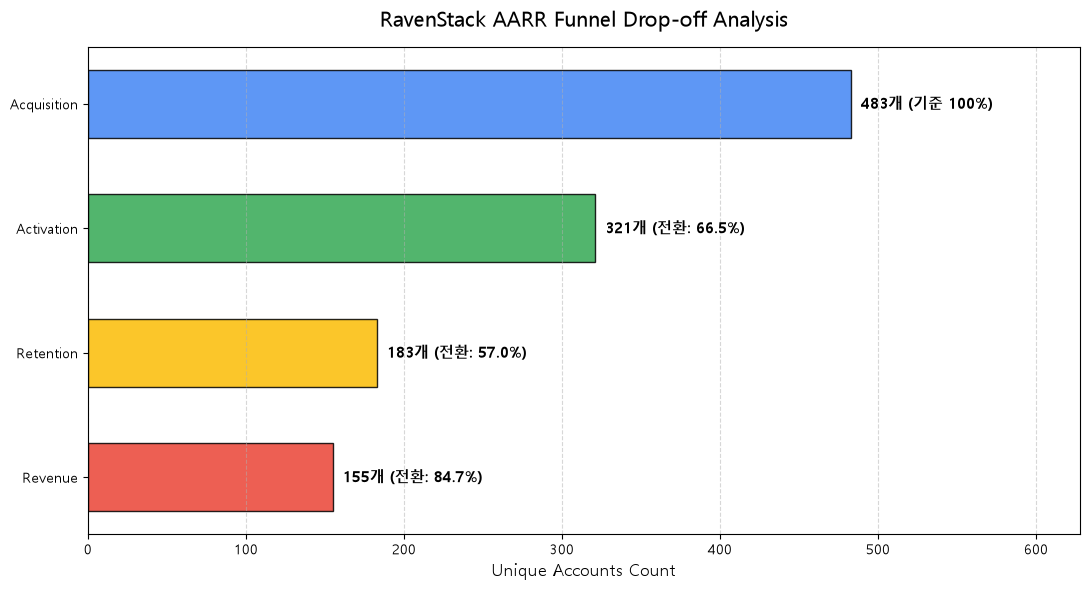


[최저 전환 단계]: Retention
[이탈 집중 구간]: Activation → Retention
[해당 구간 전환율]: 57.0% (이탈률: 43.0%)


In [3]:
# 필수 2 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# ====================================================
# 1~3. funnel_summary를 이용한 가로 막대그래프(barh) 시각화
# ====================================================
# 필수 1에서 생성한 funnel_summary 사용
# (가로 막대그래프는 아래에서 위로 그려지므로 위에서 아래로 순서가 보이게 역순 정렬)
plot_df = funnel_summary.iloc[::-1].copy()

plt.figure(figsize=(11, 6))
bars = plt.barh(
    plot_df.index,
    plot_df["accounts"],
    color=["#EA4335", "#FBBC05", "#34A853", "#4285F4"],
    edgecolor="black",
    height=0.55,
    alpha=0.85,
)

# 막대 옆에 [계정 수 (전 단계 대비 전환율)] 텍스트 레이블 표시
max_acc = plot_df["accounts"].max()
for bar, stage in zip(bars, plot_df.index):
    width = bar.get_width()
    conv = plot_df.loc[stage, "step_conv"]

    # 첫 단계(Acquisition)는 기준(100%), 이후 단계는 전 단계 대비 전환율 표시
    if stage == "Acquisition":
        label_text = f"  {width:,}개 (기준 100%)"
    else:
        label_text = f"  {width:,}개 (전환: {conv:.1%})"

    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2.0,
        label_text,
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

plt.title("RavenStack AARR Funnel Drop-off Analysis", fontsize=15, pad=15)
plt.xlabel("Unique Accounts Count", fontsize=12)
plt.xlim(0, max_acc * 1.3)  # 레이블이 잘리지 않도록 x축 여유 공간 확보
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ====================================================
# 4~5. 첫 단계를 제외하고 전 단계 대비 전환율 최저 단계 및 구간 찾기
# ====================================================
# 첫 단계(Acquisition) 제외
subsequent_stages = funnel_summary.iloc[1:].copy()

# 최저 전환율 단계 찾기
lowest_stage = subsequent_stages["step_conv"].idxmin()
lowest_conv = subsequent_stages.loc[lowest_stage, "step_conv"]

# 해당 단계의 직전 단계 찾기
stages_list = list(funnel_summary.index)
lowest_stage_idx = stages_list.index(lowest_stage)
prev_stage = stages_list[lowest_stage_idx - 1]

print(f"\n[최저 전환 단계]: {lowest_stage}")
print(f"[이탈 집중 구간]: {prev_stage} → {lowest_stage}")
print(f"[해당 구간 전환율]: {lowest_conv:.1%} (이탈률: {1.0 - lowest_conv:.1%})")

### 필수 2 답변 작성란

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  
- Retention 단계가 64.5%로 가장 낮음, 이탈 구간은 Activation -> Retention

**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
- 아니오. 퍼널은 이탈률이 높은 구간을 알 수 있을 뿐, 구체적인 원인 파악은 추가적인 데이터 분석이 필요하다.

**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?
- 오류 수, 오류 종류, 고객 지원, 프로모션 등

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 첫 구독 요금제별 퍼널 비교와 개선 가설 제안하기

#### 문제 설명

첫 구독의 plan_tier별로 Acquisition → Activation → Retention → Revenue 단계의 계정 수와 전환율을 비교하세요. 이탈이 집중된 구간을 찾고, 개선 가설과 검증 방법을 제안하세요.

> 필수 문제의 단계 정의와 집계·전환율 계산·시각화 절차를 그대로 활용합니다. Referral은 관련 행동 기록이 없어 분석에서 제외합니다.

#### 요구사항

1. 원시 계정·구독·기능 사용 데이터를 연결하여 funnel_base와 단계 도달 여부를 만드는 코드를 제출물에 포함하세요. 필수 문제에서 작성한 코드를 재사용해도 됩니다.
2. 첫 구독의 plan_tier별로 Acquisition, Activation, Retention, Revenue의 고유 계정 수를 집계하세요. 각 단계에는 이전 단계에 도달한 계정만 포함하세요.
3. 요금제별로 다음 값을 계산하여 plan_funnel을 만드세요.
- 구간 전환율 = 현재 단계 계정 수 ÷ 이전 단계 계정 수 × 100
- 구간 이탈률 = 100 − 구간 전환율
- 구간 이탈 계정 수 = 이전 단계 계정 수 − 현재 단계 계정 수
- 첫 단계는 비교할 이전 단계가 없으므로 구간 지표를 빈 값으로 두세요. 이전 단계 계정 수가 0이면 전환율·이탈률을 계산 불가로 표시하세요.
4. 요금제별로 단계별 고유 계정 수를 가로 막대그래프로 시각화하고, 각 단계의 구간 전환율을 함께 표시하세요.
5. 첫 단계를 제외하고 전환율이 가장 낮은 요금제·구간 조합을 찾으세요. 해당 구간의 전환율·이탈률·이탈 계정 수를 근거로 이탈 집중 구간을 설명하세요.
6. 요금제별 최종 Revenue 도달률을 계산하여 plan_summary로 출력하세요. 가장 높은 요금제와 낮은 요금제의 차이를 %p로 계산하세요.
- 최종 Revenue 도달률 = Revenue 계정 수 ÷ Acquisition 계정 수 × 100
7. 우선 점검할 구간에 대해 “어떤 원인 때문에 이탈하며, 어떤 변경을 하면 전환율이 개선될 것이다”라는 개선 가설을 한 가지 작성하세요.
8. 가설을 확인하기 위한 추가 데이터 2가지와 검증 방법을 설명하세요. 어떤 대상을 비교하고 어떤 지표로 개선 여부를 판단할지 포함하세요. 실제 실험이나 통계 검정은 수행하지 않아도 됩니다.

#### 해석 질문

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?

#### 제출 결과

- 원시 데이터 연결 및 단계 도달 여부 구성 코드
- plan_funnel: 단계별 계정 수·전환율·이탈률·이탈 계정 수
- 요금제별 퍼널 그래프
- 이탈 집중 구간과 수치 근거
- plan_summary: 최종 Revenue 도달률과 최고·최저 차이
- 개선 가설·추가 확인 데이터 2가지·검증 방법
- Q1~Q4 답변

=== [결과 1] 첫 구독 요금제별 퍼널 테이블 (plan_funnel) ===


,plan_tier,stage,accounts,step_conv_rate,step_drop_rate,dropped_accounts
0,Basic,Acquisition,161,-,-,-
1,Basic,Activation,101,62.73%,37.27%,60개
2,Basic,Retention,61,60.40%,39.60%,40개
3,Basic,Revenue,49,80.33%,19.67%,12개
4,Pro,Acquisition,159,-,-,-
5,Pro,Activation,101,63.52%,36.48%,58개
6,Pro,Retention,59,58.42%,41.58%,42개
7,Pro,Revenue,52,88.14%,11.86%,7개
8,Enterprise,Acquisition,163,-,-,-
9,Enterprise,Activation,119,73.01%,26.99%,44개


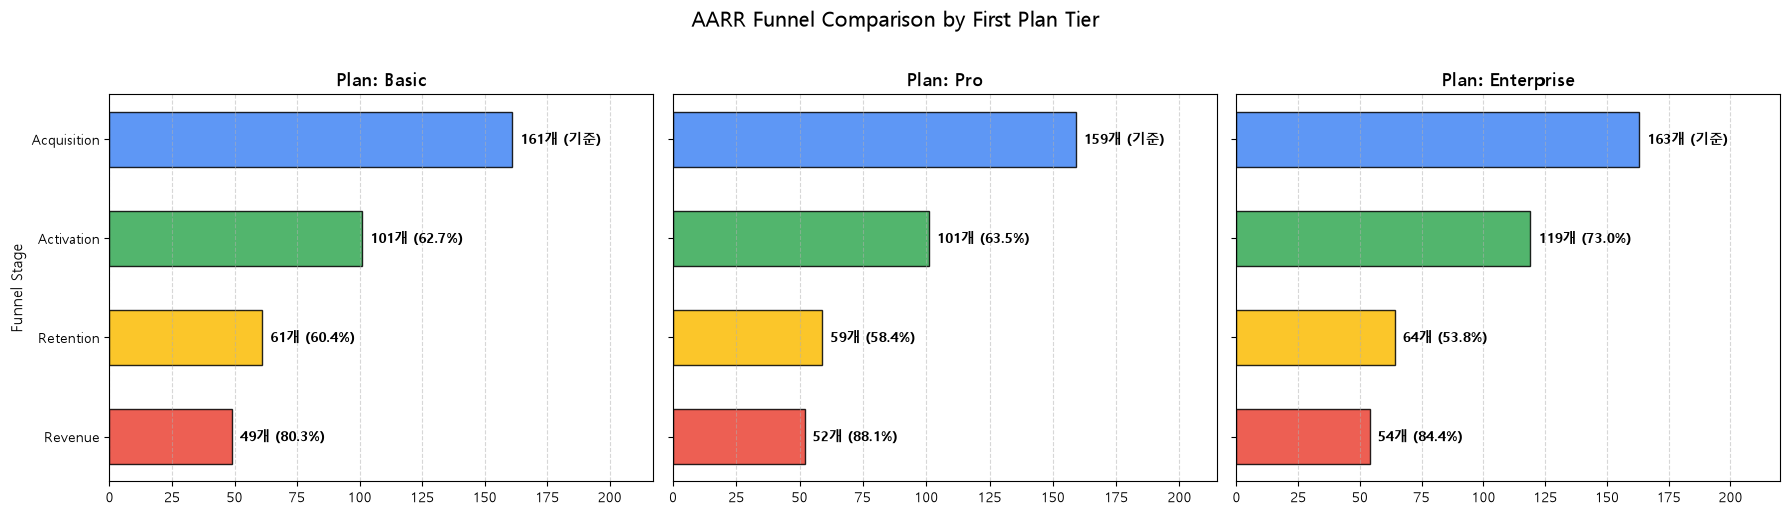


[최저 전환율 구간 조합]
- 요금제: Enterprise
- 구간: Activation → Retention
- 전환율: 53.78%
- 이탈률: 46.22%
- 이탈 계정 수: 55개

=== [결과 2] plan_summary (최종 Revenue 도달률) ===


,plan_tier,Acquisition,Revenue,final_revenue_rate(%)
0,Basic,161,49,30.43%
1,Pro,159,52,32.70%
2,Enterprise,163,54,33.13%



최고 도달률: Enterprise (33.13%)
최저 도달률: Basic (30.43%)
최고 - 최저 격차: 2.69%p


In [4]:
# 과제 1 코드를 작성하세요.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====================================================
# 1. 원시 데이터 연결 및 단계 도달 여부 구성 (funnel_base)
# ====================================================
# 관찰 기준일 (마지막 기능 사용일 - 30일)
observation_cutoff = feature_usage["usage_date"].max() - pd.Timedelta(days=30)

# 계정별 가장 이른 첫 구독 (first_subscription)
first_subscription = (
    subscriptions.sort_values(
        by=["account_id", "start_date", "subscription_id"]
    )
    .groupby("account_id")
    .first()
    .reset_index()
)

# 첫 구독과 feature_usage 결합 후 유효 기능 사용 (valid_usage)
usage_with_first = feature_usage.merge(
    first_subscription[
        [
            "subscription_id",
            "account_id",
            "start_date",
            "end_date",
            "is_trial",
            "mrr_amount",
            "plan_tier",
        ]
    ],
    on="subscription_id",
    how="inner",
)

valid_condition = (
    usage_with_first["usage_date"] >= usage_with_first["start_date"]
) & (
    usage_with_first["end_date"].isna()
    | (usage_with_first["usage_date"] <= usage_with_first["end_date"])
)
valid_usage = usage_with_first[valid_condition].copy()

# funnel_base 생성 (관찰 기준일 이전 가입 계정)
funnel_base = accounts[accounts["signup_date"] <= observation_cutoff].copy()

# 첫 구독 정보 병합 (first_sub의 plan_tier, is_trial, mrr_amount 연결)
first_sub_info = first_subscription[
    [
        "account_id",
        "subscription_id",
        "start_date",
        "plan_tier",
        "is_trial",
        "mrr_amount",
    ]
].rename(
    columns={
        "start_date": "first_sub_date",
        "plan_tier": "first_plan_tier",
        "is_trial": "sub_is_trial",
        "mrr_amount": "sub_mrr",
    }
)
funnel_base = funnel_base.merge(first_sub_info, on="account_id", how="left")

# --- 누적 퍼널 단계별 불리언 조건 생성 ---
# [Acquisition]
funnel_base["is_acq"] = True

# [Activation]: 가입 후 30일 이내 첫 구독 시작
days_to_sub = (
    funnel_base["first_sub_date"] - funnel_base["signup_date"]
).dt.days
funnel_base["is_act"] = (
    funnel_base["is_acq"]
    & funnel_base["first_sub_date"].notna()
    & (days_to_sub >= 0)
    & (days_to_sub <= 30)
)

# [Retention]: Activation 통과 & 첫 구독 시작 30일 후 유효 기능 사용 기록 존재
usage_after_30d = valid_usage[
    valid_usage["usage_date"]
    >= valid_usage["start_date"] + pd.Timedelta(days=30)
]
retained_accs = set(usage_after_30d["account_id"])
funnel_base["is_ret"] = funnel_base["is_act"] & funnel_base[
    "account_id"
].isin(retained_accs)

# [Revenue]: Retention 통과 & 첫 구독이 체험판이 아니고 sub_mrr > 0
funnel_base["is_rev"] = (
    funnel_base["is_ret"]
    & (funnel_base["sub_is_trial"] == False)
    & (funnel_base["sub_mrr"] > 0)
)

# ====================================================
# 2~3. 첫 구독 요금제(first_plan_tier)별 퍼널 지표 집계 (plan_funnel)
# ====================================================
plans = ["Basic", "Pro", "Enterprise"]
stages = ["Acquisition", "Activation", "Retention", "Revenue"]
stage_cols = ["is_acq", "is_act", "is_ret", "is_rev"]

plan_funnel_records = []

for plan in plans:
    plan_data = funnel_base[funnel_base["first_plan_tier"] == plan]

    counts = [plan_data[col].sum() for col in stage_cols]

    for i, (stage, count) in enumerate(zip(stages, counts)):
        if i == 0:
            conv_rate = np.nan
            drop_rate = np.nan
            drop_accounts = np.nan
        else:
            prev_count = counts[i - 1]
            if prev_count == 0:
                conv_rate = np.nan
                drop_rate = np.nan
                drop_accounts = 0
            else:
                conv_rate = (count / prev_count) * 100.0
                drop_rate = 100.0 - conv_rate
                drop_accounts = prev_count - count

        plan_funnel_records.append(
            {
                "plan_tier": plan,
                "stage": stage,
                "accounts": count,
                "step_conv_rate": conv_rate,
                "step_drop_rate": drop_rate,
                "dropped_accounts": drop_accounts,
            }
        )

plan_funnel = pd.DataFrame(plan_funnel_records)

print("=== [결과 1] 첫 구독 요금제별 퍼널 테이블 (plan_funnel) ===")
# 가독성을 위한 포맷팅 출력
display_plan_funnel = plan_funnel.copy()
display_plan_funnel["step_conv_rate"] = display_plan_funnel[
    "step_conv_rate"
].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "-")
display_plan_funnel["step_drop_rate"] = display_plan_funnel[
    "step_drop_rate"
].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "-")
display_plan_funnel["dropped_accounts"] = display_plan_funnel[
    "dropped_accounts"
].map(lambda x: f"{int(x):,}개" if pd.notna(x) else "-")
display(display_plan_funnel)

# ====================================================
# 4. 요금제별 단계별 계정 수 및 전환율 가로 막대그래프 시각화
# ====================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, plan in zip(axes, plans):
    sub_df = (
        plan_funnel[plan_funnel["plan_tier"] == plan].iloc[::-1].reset_index()
    )
    bars = ax.barh(
        sub_df["stage"],
        sub_df["accounts"],
        color=["#EA4335", "#FBBC05", "#34A853", "#4285F4"],
        edgecolor="black",
        height=0.55,
        alpha=0.85,
    )

    max_val = sub_df["accounts"].max()
    for bar, (_, row) in zip(bars, sub_df.iterrows()):
        w = bar.get_width()
        conv_text = (
            f" ({row['step_conv_rate']:.1f}%)"
            if pd.notna(row["step_conv_rate"])
            else " (기준)"
        )
        ax.text(
            w + (max_val * 0.02),
            bar.get_y() + bar.get_height() / 2.0,
            f"{int(w):,}개{conv_text}",
            va="center",
            ha="left",
            fontweight="bold",
            fontsize=10,
        )

    ax.set_title(f"Plan: {plan}", fontsize=13, fontweight="bold")
    ax.set_xlim(0, max_val * 1.35)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

axes[0].set_ylabel("Funnel Stage", fontsize=11)
plt.suptitle(
    "AARR Funnel Comparison by First Plan Tier", fontsize=15, y=1.02
)
plt.tight_layout()
plt.show()

# ====================================================
# 5. 전환율이 가장 낮은 요금제·구간 조합 탐색
# ====================================================
valid_transitions = plan_funnel.dropna(subset=["step_conv_rate"]).copy()
lowest_row = valid_transitions.loc[
    valid_transitions["step_conv_rate"].idxmin()
]

# 이전 단계 찾기
curr_stage = lowest_row["stage"]
curr_stage_idx = stages.index(curr_stage)
prev_stage = stages[curr_stage_idx - 1]

print(f"\n[최저 전환율 구간 조합]")
print(f"- 요금제: {lowest_row['plan_tier']}")
print(f"- 구간: {prev_stage} → {curr_stage}")
print(f"- 전환율: {lowest_row['step_conv_rate']:.2f}%")
print(f"- 이탈률: {lowest_row['step_drop_rate']:.2f}%")
print(f"- 이탈 계정 수: {int(lowest_row['dropped_accounts']):,}개")

# ====================================================
# 6. 요금제별 최종 Revenue 도달률 (plan_summary)
# ====================================================
summary_records = []
for plan in plans:
    acq_count = plan_funnel[
        (plan_funnel["plan_tier"] == plan)
        & (plan_funnel["stage"] == "Acquisition")
    ]["accounts"].values[0]
    rev_count = plan_funnel[
        (plan_funnel["plan_tier"] == plan) & (plan_funnel["stage"] == "Revenue")
    ]["accounts"].values[0]

    final_rev_rate = (
        (rev_count / acq_count) * 100.0 if acq_count > 0 else np.nan
    )
    summary_records.append(
        {
            "plan_tier": plan,
            "Acquisition": acq_count,
            "Revenue": rev_count,
            "final_revenue_rate(%)": final_rev_rate,
        }
    )

plan_summary = pd.DataFrame(summary_records)
highest_plan_row = plan_summary.loc[
    plan_summary["final_revenue_rate(%)"].idxmax()
]
lowest_plan_row = plan_summary.loc[
    plan_summary["final_revenue_rate(%)"].idxmin()
]
rate_diff = (
    highest_plan_row["final_revenue_rate(%)"]
    - lowest_plan_row["final_revenue_rate(%)"]
)

print("\n=== [결과 2] plan_summary (최종 Revenue 도달률) ===")
display_summary = plan_summary.copy()
display_summary["final_revenue_rate(%)"] = display_summary[
    "final_revenue_rate(%)"
].map(lambda x: f"{x:.2f}%")
display(display_summary)
print(
    f"\n최고 도달률: {highest_plan_row['plan_tier']} ({highest_plan_row['final_revenue_rate(%)']:.2f}%)"
)
print(
    f"최저 도달률: {lowest_plan_row['plan_tier']} ({lowest_plan_row['final_revenue_rate(%)']:.2f}%)"
)
print(f"최고 - 최저 격차: {rate_diff:.2f}%p")

### 과제 1 답변 작성란

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?
- Enterprise / Activation -> Retention 
- 전환율 53.78% / 이탈률 46.22% / 이탈 계정 수 55개

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?
- Enterprise / Basic 2.7%p 차이

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?
- Activation -> Retention 구간
- 개선 가설: 한 번 기능을 이용해 본 고객이 지속적으로 이용하지 않는 것은 이용하는데에 문제 및 불편 사항이 있거나, 타사 상품 대비 메리트가 떨어지는 부분이 크게 작용했기 때문일 수 있다.
- 고객 문의사항이나 건의사항, 이탈 설문조사 등의 데이터를 조사하거나, 동일 기간 경쟁업체의 프로모션 진행 여부 및 내용을 조사한다.

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?
- 아니오. 요금제별로 구간마다 차이는 상이하나 오히려 모든 요금제가 같은 패턴을 보이고 있으므로 다른 요인이 더욱 크게 작용했을 가능성이 크다. 요금제는 속성일뿐, 그 자체가 이탈의 원인이라고 볼 수는 없다.




## 실습 마무리

1. 이번 분석에서는 각 AARR 단계를 어떤 조건으로 정의했나요?
- 유입, 활성화, 재구독, 유료 전환 

2. 단계별 고유 계정 수는 어떤 코드로 집계했나요?
- groupby('stage')['account_id'].nunique()

3. 전 단계 대비 전환율과 전체 대비 전환율은 각각 무엇을 보여주나요?
- 전자: 바로 이전 단계에서 유지(이동)한 비율
- 후자: Acquisition 계정 중 현재 단계까지 남은 비율

4. 어느 구간에서 이탈이 가장 집중되었나요?
- 64.5%, Activation -> Retention 구간

5. 퍼널 수치와 이탈 원인을 왜 구분해야 하나요?
- 퍼널은 이탈 단계를 보여주지만 이탈 원인을 직접적으로 알려주지 않는다.

6. Referral 단계를 이번 분석에서 제외한 이유는 무엇인가요?
- 다른 사용자를 추천한 행동이나 추천 성공을 나타내는 이벤트가 없었다.